### General Imports:


In [ ]:
import os
import gymnasium as gym
from stable_baselines3.ppo import PPO
from stable_baselines3.ppo.policies import MlpPolicy as MLP_PPO
from stable_baselines3.common.monitor import Monitor
import matplotlib.pyplot as plt
import seaborn as sns
from netsim.gym_basic.envs import RMSA_ENV
from netsim.netSimPy import *
from sklearn import tree
from stable_baselines3.common.callbacks import EvalCallback
import numpy as np
import tensorflow as tf
import logging
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

logging.getLogger("tensorflow").setLevel(logging.FATAL)
tf.__version__
from stable_baselines3.common.vec_env import (
    DummyVecEnv,
    is_vecenv_wrapped,
)

/Users/jbcedeno/Documents/netsim/.netsim_env/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/jbcedeno/Documents/netsim/.netsim_env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# FILES AND DIRECTORIES:
__file__ = "RMSA.ipynb"
absolutepath = os.path.abspath(__file__)
file_name = os.path.basename(os.path.abspath(__file__)).split(".")[0]
log_dir = f"./tmp/{file_name}/"
# SIMULATION PARAMS:
EPISODE_LENGTH = 1000
N_BLOCKS = 5
N_PATHS = 3
M_LAMBDA = 50000  # 500 Erlangs

networkPaths = "/Users/jbcedeno/Documents/projcts/multiband-gymnasium/networks/nsfnet"
network = Network(
    networkFileName=networkPaths + "/network.json",
    pathsFileName=networkPaths + "/routes.json",
    bitrateFilename=networkPaths + "/bitrates_c_bands.json",
)
generator = EventsGenerator(mLambda=M_LAMBDA)
sim_args = dict(eventsGenerator=generator, network=network)
simulator = NetworkSimulator(**sim_args)
# Building the environment:
env_args = dict(
    simulator=simulator,
    episode_length=EPISODE_LENGTH,
    j=N_BLOCKS,
    n_paths=N_PATHS,
)

env: RMSA_ENV = Monitor(gym.make("RMSA_ENV-v0", **env_args), log_dir)
eval_env: RMSA_ENV = Monitor(gym.make("RMSA_ENV-v0", **env_args), log_dir + "eval_env")


best_model_dir = f"./tmp/RMSA_27/best_model.zip"
expert = PPO.load(best_model_dir)

In [ ]:
def generate_trajectories(n_timesteps, model, env, only_accepted=True):
    trajectories = []
    timesteps_count = 0
    state = None
    done = False
    observation = env.reset()[0]

    while timesteps_count < n_timesteps:
        act, state = model.predict(
            observation,
            state=state,
            episode_start=done,
            deterministic=True,
        )
        traj = {"obs": observation, "action": act}
        observation, reward, done, truncated, info = env.step(act)
        traj["reward"] = reward
        if only_accepted:
            if reward > 0:
                trajectories.append(traj)
                timesteps_count += 1
        else:
            trajectories.append(traj)
            timesteps_count += 1
        if done:
            env.reset()
    return trajectories


def flatten_trajectories(traj):
    obs = [t["obs"] for t in traj]
    acts = [t["action"] for t in traj]
    rewards = [t["reward"] for t in traj]
    return obs, acts, rewards


class MixerPolicy:
    def __init__(self, expert, student, beta):
        self.student = student
        self.expert = expert
        self.beta = beta

    def set(self, expert, student, beta):
        self.student = student
        self.expert = expert
        self.beta = beta

    def predict(self, observation, state, episode_start, deterministic):
        model = np.random.choice(["A", "B"], p=[self.beta, 1 - self.beta])
        if model == "A":
            return self.expert.predict(observation, state, episode_start, deterministic)
        else:
            return self.student.predict([observation])[0], None


def get_expert_acts(expert, obs, env):
    acts = []
    state = None
    done = False
    env.reset()
    for o in obs:
        act, state = expert.predict(
            o,
            state=state,
            episode_start=done,
            deterministic=True,
        )
        acts.append(act)
    return acts


def linear_beta(start, end, steps):
    def call(n):
        return max(start + n * (end - start) / (steps - 1), end)

    return call

In [ ]:
from sklearn import ensemble
from sklearn.linear_model import LogisticRegression
from IPython.display import clear_output
import pickle as pkl
import pandas as pd
import json


def decode_action(act, j):
    idx_path = act // j
    idx_block = act % j
    return idx_path, idx_block


def get_route_from_action(acts, j):
    return [decode_action(a, j)[0] for a in acts]


def evaluate_student(student, n_timesteps):
    traj = generate_trajectories(n_timesteps, expert, env)
    x_test = [t["obs"] for t in traj]
    y_test = [t["action"] for t in traj]
    # y_test =  get_route_from_action(y_test, env.j)
    y_pred = student.predict(x_test)

    conf_matrix = confusion_matrix(y_test, y_pred)
    score = accuracy_score(y_test, y_pred)
    print(score, conf_matrix)


def train_with_dagger(
    expert,
    env,
    beta_func,
    n_rounds,
    timesteps_by_round,
    on_round_change=None,
    trajes_output_name=file_name + "_trajs.csv",
):
    student_policy = LogisticRegression(multi_class="multinomial")
    print(f"Starting round 1")
    print(f"Sampling new trajectories for round: {1} ")
    # clear_output(wait=True)
    obs, acts, _rewards = flatten_trajectories(
        generate_trajectories(timesteps_by_round, expert, env)
    )

    # routes = get_route_from_action(acts, env.j)
    student_policy.fit(obs, acts)
    evaluate_student(student_policy, 100000)

    for r in range(1, n_rounds):
        print(f"Starting round {r+1}")
        mixer = MixerPolicy(expert, student_policy, beta=beta_func(r))
        print(f"Sampling new trajectories for round: {r+1} ")
        obs2, _acts, _rewards = flatten_trajectories(
            generate_trajectories(timesteps_by_round, mixer, env)
        )
        acts2 = get_expert_acts(expert, obs2, env)

        # extend and update:
        shuffle = np.arange(len(obs2))
        np.random.shuffle(shuffle)
        obs2 = [obs2[s] for s in shuffle]
        acts2 = [acts2[s] for s in shuffle]
        obs.extend(obs2)
        acts.extend(acts2)

        # print(f"Saving trajectories for round: {r+1} ")
        # df = pd.DataFrame({'x':[json.dumps(o.tolist(),separators=(',', ':')) for o in obs2], 'y':acts2})
        # df.to_csv(trajes_output_name,
        #             mode="a",
        #             index=False,
        #             header=False
        #         )
        print(f"Fitting student for round: {r+1} ")
        # clear_output(wait=True)

        # routes = get_route_from_action(acts, env.j)
        student_policy.fit(obs, acts)
        evaluate_student(student_policy, 100000)

    return student_policy

In [ ]:
n_steps = 8
beta_func = linear_beta(1, 0, n_steps)
student = train_with_dagger(expert, env, beta_func, n_steps, timesteps_by_round=300000)

Starting round 1
Sampling new trajectories for round: 1 


/Users/jbcedeno/Documents/netsim/.netsim_env/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/jbcedeno/Documents/netsim/.netsim_env/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.69462 [[47624   565   426     0     0   921   507   607     0   700   119  1219
     43]
 [ 1581  2356   567     0     0   649    60     1     0   125    41   114
     21]
 [  874   558  2110     0     0  1356   434     0     0   144    42   114
      3]
 [    1     0     0     0     0     0     0     0     0     0     0     0
      0]
 [    0     2     0     0     0     0     0     0     0     0     0     1
      0]
 [ 2815   322   977     0     0  7691   459    77     0   651   114    63
    148]
 [ 1084    15   288     0     0   458  2166    24     0   200   374   424
     43]
 [  738     6    15     0     0   306   308   363     0    44    52    70
     13]
 [    0     0     0     0     0     1     0     0     0     1     0     0
      0]
 [ 2707   162   401     0     0  1483   301    78     0  2853    29    57
     21]
 [  139     0   129     0     0   151   356    13     0    86  1141   303
      0]
 [  659    20   201     0     0   321   140    25     0     9   221  2536
    1

/Users/jbcedeno/Documents/netsim/.netsim_env/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/jbcedeno/Documents/netsim/.netsim_env/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.69725 [[47715   589   457     0   909   513   576     0   758   105  1203    48]
 [ 1407  2237   576     0   694    55     1     0   103    30   120    33]
 [  778   589  2177     0  1372   451     1     0   137    46   141     1]
 [    1     0     0     0     1     0     0     0     0     0     0     0]
 [ 2822   363  1020     0  7596   507    79     0   779   109    44   124]
 [ 1056    19   308     0   406  2281    18     0   222   402   369    39]
 [  717     3     9     0   245   325   363     0    44    50    85    19]
 [    0     0     0     0     0     1     0     0     1     0     1     0]
 [ 2708   175   443     0  1431   257    71     0  3038    29    51    17]
 [  111     1   132     0   136   319    22     0    55  1212   268     0]
 [  633    21   231     0   282   163    24     0    10   212  2468    92]
 [  168     2     0     0   252     8    14     0    19     0    37   638]]
Starting round 3
Sampling new trajectories for round: 3 
Fitting student for round: 3 


...

0.69023 [[47132   522   497     0     0   922   493   624     0   732   100  1160
     50]
 [ 1467  2228   553     0     0   673    66     4     0   112    34   108
     31]
 [  818   537  2110     0     0  1509   438     1     0   154    52   146
      1]
 [    3     0     1     0     0     0     0     0     0     0     0     0
      0]
 [    0     2     0     0     0     0     0     0     0     0     0     0
      0]
 [ 2991   347  1003     0     0  7790   510    82     0   734    94    57
    145]
 [ 1139    15   288     0     0   427  2206    35     0   201   412   419
     50]
 [  726     3     7     0     0   243   331   340     0    44    60    75
     13]
 [    2     0     0     0     0     0     0     0     0     1     0     0
      0]
 [ 2877   182   425     0     0  1479   223    53     0  2995    26    47
     29]
 [  120     0   115     0     0   189   357    26     0    78  1139   303
      0]
 [  709    25   203     0     0   290   170    23     0     8   204  2438
     

/Users/jbcedeno/Documents/netsim/.netsim_env/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/jbcedeno/Documents/netsim/.netsim_env/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.69129 [[47683   562   493     0     0   929   516   590     0   702   109  1204
     58]
 [ 1450  2168   586     0     0   716    55     0     0   130    31   107
     31]
 [  782   572  2074     0     0  1443   425     2     0   148    51   149
      1]
 [    0     0     1     0     0     1     0     0     0     0     0     0
      0]
 [    0     1     0     0     0     0     0     0     0     0     0     0
      0]
 [ 2945   351   987     0     0  7669   480    65     0   733   101    38
    145]
 [ 1057    20   247     0     0   462  2145    36     0   193   369   338
     48]
 [  719     4    15     0     0   242   313   349     0    54    52    66
     15]
 [    1     0     0     0     0     0     1     0     0     0     0     0
      0]
 [ 3015   202   394     0     0  1468   239    49     0  2823    17    74
     20]
 [  103     2   102     0     0   205   382    27     0    78  1027   354
      0]
 [  643    24   201     0     0   311   202    30     0    11   198  2597
     

/Users/jbcedeno/Documents/netsim/.netsim_env/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/jbcedeno/Documents/netsim/.netsim_env/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.69527 [[47951   552   484     0     0   935   484   550     0   657    97  1135
     35]
 [ 1436  2225   588     0     0   680    48     0     0   129    44   128
     25]
 [  842   497  2099     0     0  1398   419     2     0   141    43   126
      2]
 [    4     0     0     0     0     0     0     0     0     1     0     0
      0]
 [    1     0     0     0     0     0     0     0     0     2     0     1
      0]
 [ 2765   335  1076     0     0  7640   484    74     0   659    84    51
    140]
 [ 1109    19   286     0     0   449  2190    21     0   160   423   420
     51]
 [  734     2     9     0     0   294   297   311     0    41    63    55
     16]
 [    2     0     0     0     0     0     0     0     0     0     0     0
      0]
 [ 2948   162   426     0     0  1577   255    60     0  2741    31    44
     18]
 [  126     1   123     0     0   179   355    26     0    94  1196   299
      0]
 [  683    20   208     0     0   296   154    21     0    12   200  2544
     

### Saving the agent


In [ ]:
pickle_out = open("student_LGR.pkl", "wb")
pkl.dump(student, pickle_out)
pickle_out.close()
# pickle_out = open("student_LGR.pkl","rb")
# student = pkl.load(pickle_out)
# pickle_out.close()

In [ ]:
def get_actions_count(y_test):
    y1_test = [0] * 15
    for yv in y_test:
        y1_test[yv] += 1
    return y1_test

### Global accuracy


In [ ]:
traj = generate_trajectories(200000, expert, env)
x_test = [t["obs"] for t in traj]
y_test = [int(t["action"]) for t in traj]

# y_pred = predict(x_test,student, env)
y_pred = student.predict(x_test)
score = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred, labels=[i for i in range(15)])
print(score)
print(conf_matrix)
print(f1_score(y_test, y_pred, average="weighted"))

0.69434
[[95398  1086   868     0     0  1789   948  1233     0     0  1370   201
   2209    78     0]
 [ 2961  4527  1214     0     0  1379   102     2     0     0   239    89
    234    59     0]
 [ 1703  1013  4106     0     0  2871   890     0     0     0   308   108
    249     1     0]
 [    3     0     2     0     0     0     0     0     0     0     1     0
      0     0     0]
 [    1     3     1     0     0     1     0     0     0     0     0     0
      2     0     0]
 [ 5680   710  2019     0     0 15548   930   135     0     0  1349   225
    109   304     0]
 [ 2218    39   552     0     0   846  4348    54     0     0   416   796
    745    99     0]
 [ 1458     4    40     0     0   594   631   608     0     0    81    95
    116    41     0]
 [    1     0     0     0     0     0     0     1     0     0     1     0
      0     0     0]
 [    0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0]
 [ 5806   346   874     0     0  3085   46

In [21]:
get_metrics(conf_matrix)

Clase 1:
  Precision: 0.8788
  F1-score: 0.8952
  Sensibilidad (Recall): 0.9123
  Especificidad: 10.4021

Clase 2:
  Precision: 0.6031
  F1-score: 0.5495
  Sensibilidad (Recall): 0.5046
  Especificidad: 1.0187

Clase 3:
  Precision: 0.4790
  F1-score: 0.4648
  Sensibilidad (Recall): 0.4514
  Especificidad: 0.8227

Clase 4:
  Precision: 0.6174
  F1-score: 0.5978
  Sensibilidad (Recall): 0.5795
  Especificidad: 1.3781

Clase 5:
  Precision: nan
  F1-score: nan
  Sensibilidad (Recall): 0.0000
  Especificidad: 0.0000



/var/folders/k2/q0rx2fz13mn6n61q8bpqwxtm0000gn/T/ipykernel_11490/2585605376.py:3: RuntimeWarning: invalid value encountered in divide
  precision = np.diag(confusion_matrix) / np.sum(confusion_matrix, axis=0)


### Inter-path accuracy


In [ ]:
n_conf_matrix = np.zeros(shape=(3, 3))
for ir, row in enumerate(conf_matrix):
    for ic, col in enumerate(row):
        n_conf_matrix[ir // 5, ic // 5] += conf_matrix[ir][ic]


def score(matrix):
    total = sum(matrix.reshape(-1, 1))
    correct = np.trace(matrix)
    return correct / total


s = score(n_conf_matrix)
print(s[0])
print(n_conf_matrix)

0.763235
[[112886.   9215.   5148.]
 [ 12721.  23695.   4377.]
 [  9649.   6243.  16066.]]


In [ ]:
def get_metrics(matrix):
    # Calcula métricas
    precision = np.diag(confusion_matrix) / np.sum(confusion_matrix, axis=0)
    recall = np.diag(confusion_matrix) / np.sum(confusion_matrix, axis=1)
    specificity = np.diag(confusion_matrix) / (
        np.sum(confusion_matrix, axis=1) - np.diag(confusion_matrix)
    )
    f1_score = 2 * (precision * recall) / (precision + recall)

    # Imprime las métricas
    for i in range(len(precision)):
        print(f"Clase {i + 1}:")
        print(f"  Precision: {precision[i]:.4f}")
        print(f"  F1-score: {f1_score[i]:.4f}")
        print(f"  Sensibilidad (Recall): {recall[i]:.4f}")
        print(f"  Especificidad: {specificity[i]:.4f}\n")


# Matriz de confusión proporcionada
confusion_matrix = np.array(n_conf_matrix)

get_metrics(confusion_matrix)

Clase 1:
  Precision: 0.8346
  F1-score: 0.8601
  Sensibilidad (Recall): 0.8871
  Especificidad: 7.8595

Clase 2:
  Precision: 0.6052
  F1-score: 0.5928
  Sensibilidad (Recall): 0.5809
  Especificidad: 1.3858

Clase 3:
  Precision: 0.6278
  F1-score: 0.5583
  Sensibilidad (Recall): 0.5027
  Especificidad: 1.0109



### Inter-spectrum accuracy


In [ ]:
n2_conf_matrix = np.zeros(shape=(5, 5))
for ir, row in enumerate(conf_matrix):
    for ic, col in enumerate(row):
        n2_conf_matrix[ir % 5, ic % 5] += conf_matrix[ir][ic]


def score(matrix):
    total = sum(matrix.reshape(-1, 1))
    correct = np.trace(matrix)
    return correct / total


s = score(n2_conf_matrix)
print(s[0])
print(n2_conf_matrix)

0.80239
[[1.35696e+05 4.95600e+03 7.67000e+03 4.19000e+02 0.00000e+00]
 [8.80100e+03 1.29130e+04 3.71700e+03 1.58000e+02 0.00000e+00]
 [9.10100e+03 3.52800e+03 1.05750e+04 2.25000e+02 0.00000e+00]
 [8.13000e+02 1.20000e+01 1.14000e+02 1.29400e+03 0.00000e+00]
 [2.00000e+00 3.00000e+00 3.00000e+00 0.00000e+00 0.00000e+00]]


In [17]:
# Matriz de confusión proporcionada
confusion_matrix = np.array(n2_conf_matrix)

get_metrics(confusion_matrix)

Clase 1:
  Precision: 0.8788
  F1-score: 0.8952
  Sensibilidad (Recall): 0.9123
  Especificidad: 10.4021

Clase 2:
  Precision: 0.6031
  F1-score: 0.5495
  Sensibilidad (Recall): 0.5046
  Especificidad: 1.0187

Clase 3:
  Precision: 0.4790
  F1-score: 0.4648
  Sensibilidad (Recall): 0.4514
  Especificidad: 0.8227

Clase 4:
  Precision: 0.6174
  F1-score: 0.5978
  Sensibilidad (Recall): 0.5795
  Especificidad: 1.3781

Clase 5:
  Precision: nan
  F1-score: nan
  Sensibilidad (Recall): 0.0000
  Especificidad: 0.0000



/var/folders/k2/q0rx2fz13mn6n61q8bpqwxtm0000gn/T/ipykernel_11490/2585605376.py:3: RuntimeWarning: invalid value encountered in divide
  precision = np.diag(confusion_matrix) / np.sum(confusion_matrix, axis=0)


In [ ]:
def evaluate_bp_student(student, n_timesteps, mLambda):
    timesteps_count = 0
    state = None
    done = False
    env.setLambda(mLambda)
    observation = env.reset()[0]
    accepted_requests = 0

    while timesteps_count < n_timesteps:
        # act = predict([observation], student, env)[0]
        act = student.predict([observation])[0]
        observation, reward, done, truncated, info = env.step(act)
        if reward == 1:
            accepted_requests += 1
        if done:
            env.reset()
        timesteps_count += 1
    return 1 - accepted_requests / n_timesteps


def evaluate_expert(expert, n_timesteps, mLambda):
    timesteps_count = 0
    state = None
    done = False
    env.setLambda(mLambda)
    observation = env.reset()
    accepted_requests = 0

    while timesteps_count < n_timesteps:
        act, state = expert.predict(
            observation,
            state=state,
            episode_start=done,
            deterministic=True,
        )
        observation, reward, done, truncated, info = env.step(act)
        if reward == 1:
            accepted_requests += 1
        if done:
            env.reset()
        timesteps_count += 1
    return 1 - accepted_requests / n_timesteps


loads = [
    1000,
    1200,
    1400,
    1600,
    1800,
    2000,
]
results = {
    "model": [],
    "student": [],
}
N_EVALUATIONS = 400000

for l in loads:
    env.setAllocatorFunc(None)
    # agent_model, _ = evaluate_policy(env, n_eval_episodes=N_EVALUATION_EPISODES, model = model, return_dataframe=False, return_episode_rewards=False, seed=1)
    bp = evaluate_expert(expert, N_EVALUATIONS, l)
    print("model", bp)
    results["model"].append(bp)

    bp = evaluate_bp_student(student, N_EVALUATIONS, l)
    print("student", bp)
    results["student"].append(bp)

model 7.500000000004725e-05
student 7.250000000003087e-05
model 8.249999999998536e-05
student 0.00013499999999999623
model 8.750000000001812e-05
student 0.00023499999999998522
model 0.0001974999999999616
student 0.0003975000000000506
model 0.00029999999999996696
student 0.0006549999999999612
model 0.00036000000000002697
student 0.0009799999999999809


In [ ]:
loads = [1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500]
N_EVALUATIONS = 2000000
lgr_bp = []

for l in loads:
    bp = evaluate_bp_student(student, N_EVALUATIONS, l)
    lgr_bp.append(round(bp, 7))
print(lgr_bp)

[5.75e-05, 0.0003245, 0.000909, 0.00203, 0.003861, 0.0064295, 0.0092955, 0.0127935]


### features importance


[-2.42120987e-04 -4.46860266e-05  5.47817888e-05 -1.74220545e-04
 -2.05132238e-04 -1.04647888e-04 -3.84722837e-05  1.20565502e-04
  1.33401535e-04  2.36107176e-04  8.48261534e-05  9.28202734e-05
  4.94330741e-05  0.00000000e+00  0.00000000e+00 -9.07506306e-05
 -1.56296668e-04 -7.20922454e-05 -9.20007845e-05 -1.26949089e-04
  1.46985112e-06 -3.28594281e-05  8.44399137e-05  1.28349596e-04
  3.41222136e-04 -2.94925814e-05  5.49680599e-05 -4.73525942e-05
 -4.19987495e-03  1.81927278e-02 -8.43010906e-05  7.79446716e-03
  1.65208127e-03 -6.96552384e-05 -7.36910439e-04 -1.52143436e-03
  4.16095364e-03  4.71084762e-03 -8.66049942e-04 -8.36853937e-04
 -9.19681239e-04  2.72421923e-03  9.66434108e-03  3.72585622e-03
 -2.04887769e-03  1.44510246e-03 -3.75189456e-03  2.47268307e-03
  4.29522146e-03  1.37872876e-03 -2.29925560e-03  2.76025391e-03
  3.78047963e-03 -2.84796024e-03  2.73953750e-03  7.18109751e-03
  4.31839509e-03  1.54504429e-03  2.07031370e-03 -7.91278046e-03
  3.48001990e-03 -1.47343

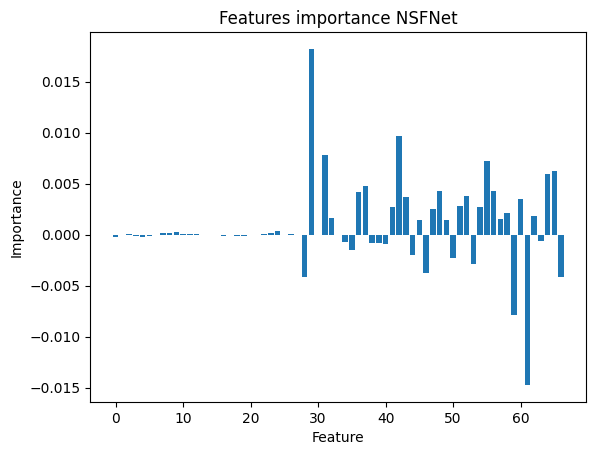

In [ ]:
import pandas as pd

base_output_dir_features = f"./plots/{__file__}/features_importance_heuristic/"

output_dir = base_output_dir_features
os.makedirs(output_dir, exist_ok=True)

# print("lolo",student.coef_[0])
# print("lolo",len(student.get_params()))

importances_sk = student.coef_[0]
importance = pd.DataFrame(importances_sk)
importance.to_csv(f"{output_dir}features_importance_heuristic.csv")
print(importances_sk)
plt.figure()
plt.bar([x for x in range(len(importances_sk))], importances_sk)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title(f"Features importance NSFNet")
plt.savefig(output_dir + "NSFNet.png")
plt.show()